<a href="https://colab.research.google.com/github/emppacs/Predictive-Modeling/blob/main/notebooks/02_Heart_Disease_Risk_Bonus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Exploratory Data Analysis and Preprocessing for Predictive Modeling
Heart Disease Risk Prediction: Binary Classification

**Dataset:** [Heart_Disease]("https://www.kaggle.com/code/poornimawari/heart-disease-uci")

**Model Used:** Random Forest Classifier

**Goal:** The objective of this analysis is to develop a high-accuracy screening tool using clinical patient data. This notebook demonstrates a full end-to-end Machine Learning pipeline—from Exploratory Data Analysis (EDA) to hyperparameter optimization.


# **1. Import Key Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
!pip install ydata_profiling

# Machine Learning Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.7 MB/s eta 0:00:00


# **2. Data Loading**

In [15]:
# Loading the UCI Heart Disease dataset
df = pd.read_csv("heart_disease_uci.csv")
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# **3. Exploratory Data Analysis (EDA)**

Missing Values per Column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


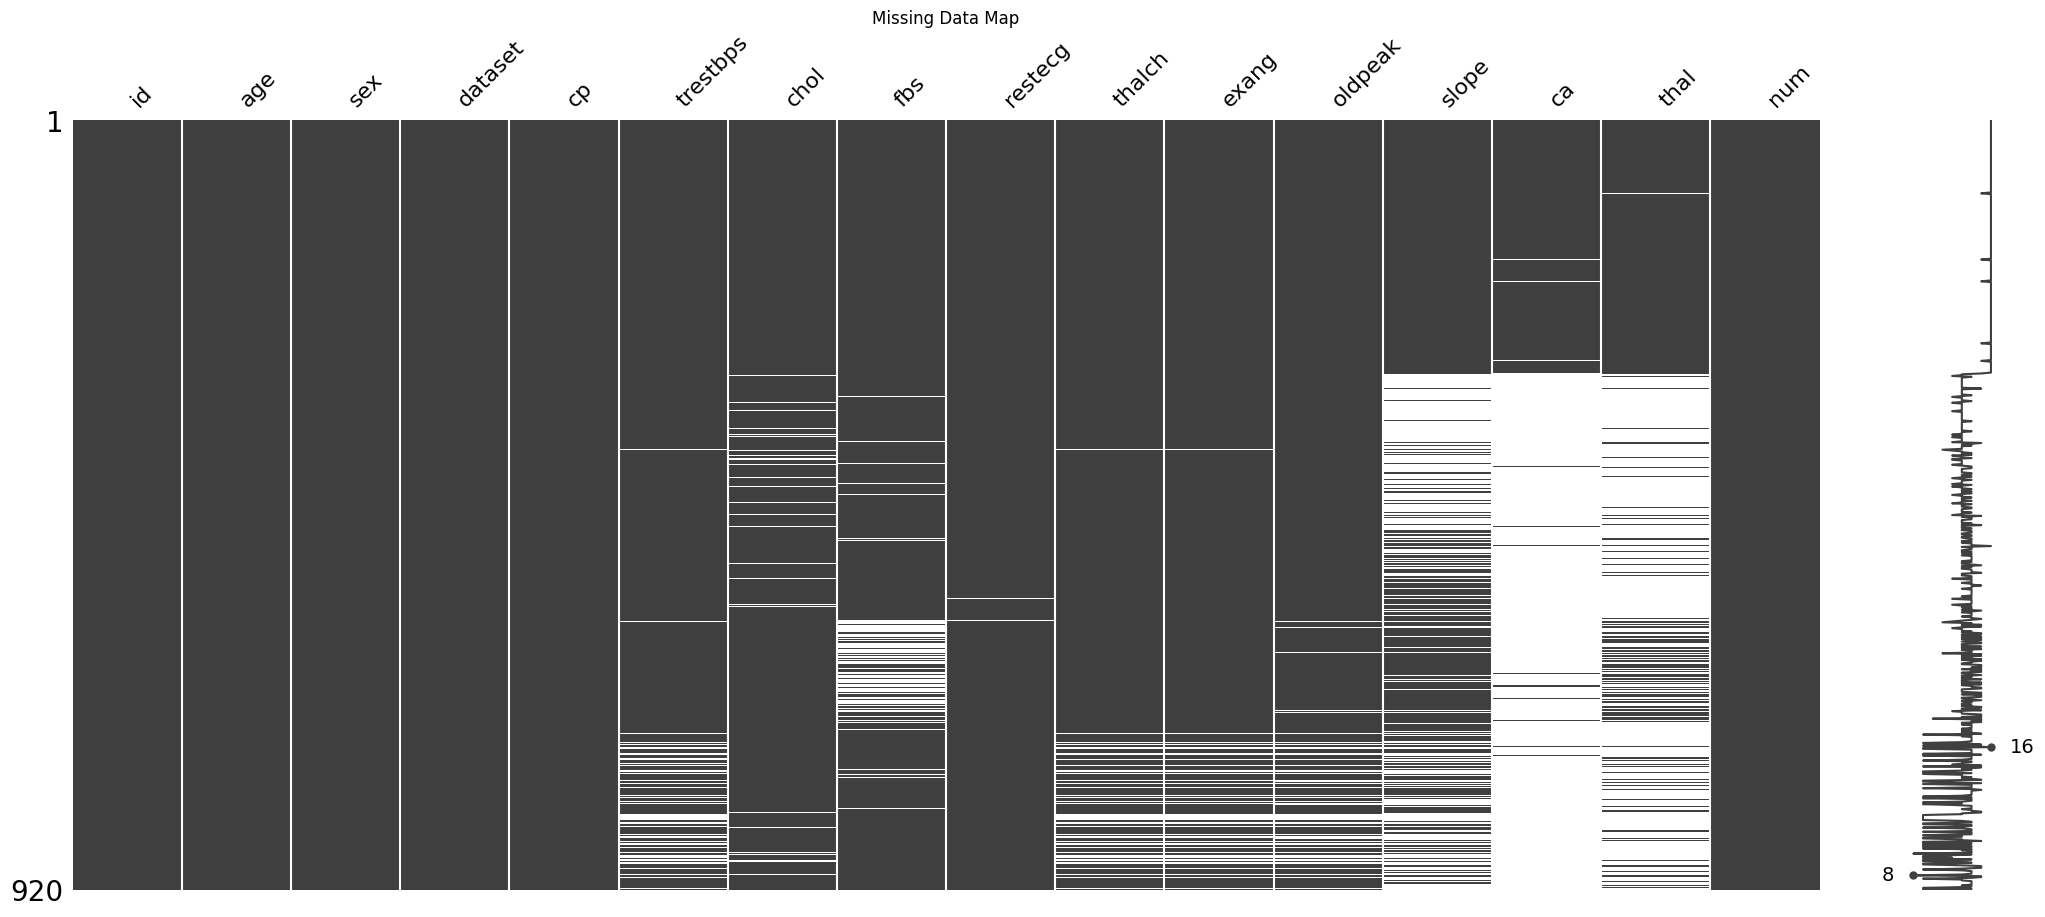

In [16]:
# Check for Missing Values
print("Missing Values per Column:")
print(df.isnull().sum())

# Visualizing Missingness
msno.matrix(df)
plt.title("Missing Data Map")
plt.show()

***Visualization***

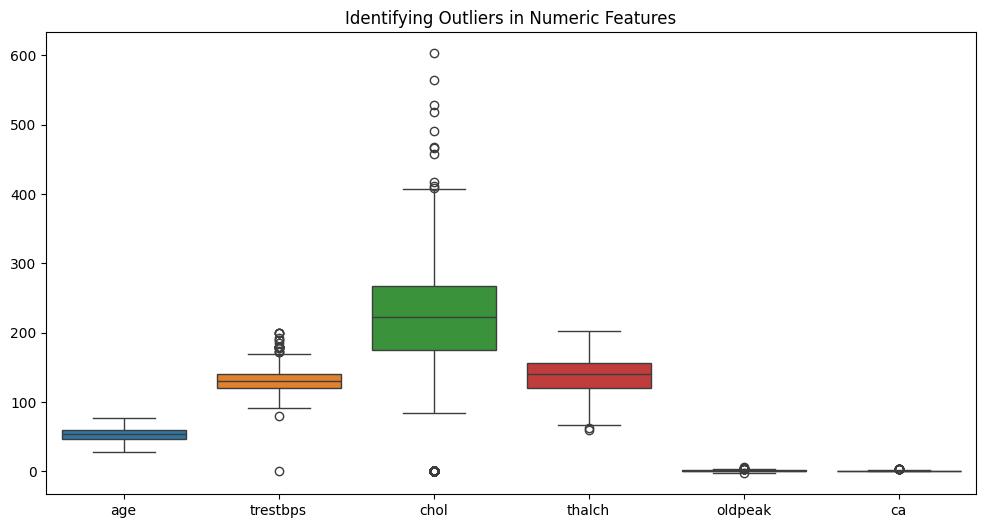

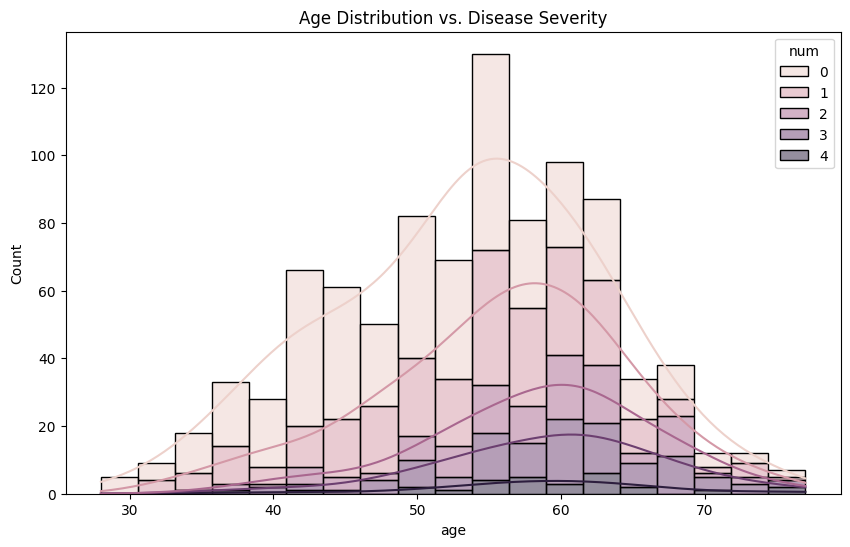

In [17]:
# Outlier Visualization (Box Plots)
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Identifying Outliers in Numeric Features")
plt.show()

# Age Distribution by Heart Disease Presence
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='num', multiple='stack', kde=True)
plt.title("Age Distribution vs. Disease Severity")
plt.show()

# Interactive Density Heatmap (Age vs Chol)
fig = px.density_heatmap(
    df, x='age', y='chol', facet_col='num',
    title='Density of Age vs Chol by Heart Disease Severity',
    template='plotly_dark'
)
fig.show()

# **4. Data Preprocessing & Pipeline**

In [18]:
# Convert 'num' to binary target (0 = No Disease, 1 = Disease Risk)
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

X = df.drop(['num', 'id'], axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Lists
NUMERIC_FEATURES = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
CATEGORICAL_FEATURES = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Ensure categoricals are strings
X_train[CATEGORICAL_FEATURES] = X_train[CATEGORICAL_FEATURES].astype(str)
X_test[CATEGORICAL_FEATURES] = X_test[CATEGORICAL_FEATURES].astype(str)

# Preprocessing Pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUMERIC_FEATURES),
    ('cat', cat_pipe, CATEGORICAL_FEATURES)
])

# Final Pipeline
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42))
])

# **5. Training and Results**

In [19]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8424

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



# **6. Feature Importance**

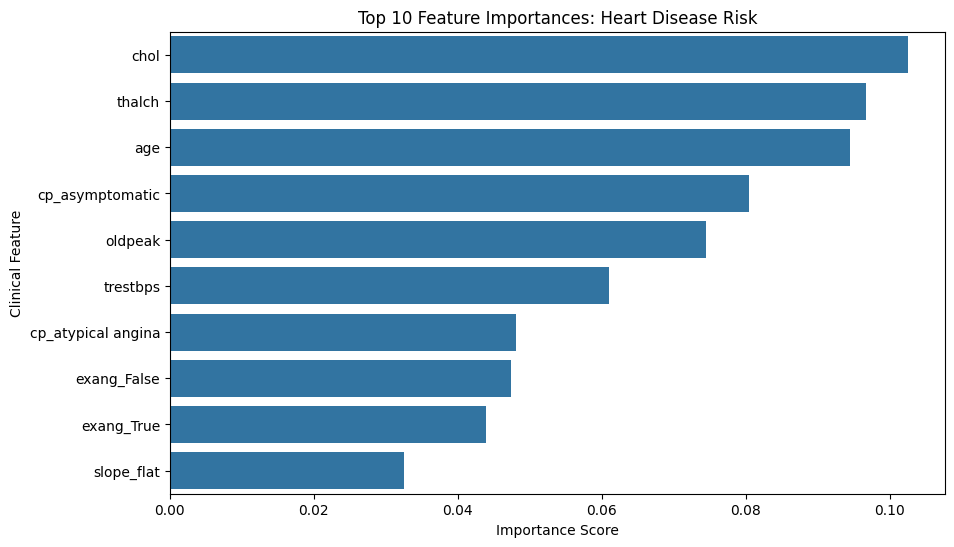

In [20]:
# 1. Get the fitted classifier and preprocessor from the pipeline
final_model = clf.named_steps['classifier']
preprocessor_fitted = clf.named_steps['preprocessor']

# 2. Get the feature names for numeric and categorical columns
numeric_features_out = NUMERIC_FEATURES
onehot_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
categorical_features_out = list(onehot_encoder.get_feature_names_out(CATEGORICAL_FEATURES))

# 3. Combine them into one list
all_feature_names = numeric_features_out + categorical_features_out

# 4. Create a DataFrame for the importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 5. Plot the Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances: Heart Disease Risk')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Feature')
plt.show()

# **7. Hyperparameter Tuning (Grid Search)**

In [21]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_split': [5, 10],
}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Accuracy: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")

Best Parameters: {'classifier__max_depth': 8, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Tuned Accuracy: 0.8533
